# 1. Set some global parameters:

In [ ]:
import pathlib
import multiprocessing as mp
import numpy as np
import numpy.typing as npt

if __name__ == "__main__":
    N_STATE = 4
    N_ITER = 200
    ALPHA = 0.11
    ATTACKER_MODEL = "random"  # "extreme_constant" or "random"
    ROOT_PATH = pathlib.Path.cwd().parent.parent
    FIGURE_PATH = ROOT_PATH / "docs" / "figures" / "large_scale"
    FIGURE_PATH.mkdir(parents=True, exist_ok=True)
    pathlib.Path(FIGURE_PATH / ATTACKER_MODEL).mkdir(parents=True, exist_ok=True)

# 2. Define the graph topology and characterize the behavior of Byzantine nodes.
## (1) Define the graph

We consider a network consisting of two categories of nodes with corresponding edges:

```python
NORMAL_NODES = [...]
NORMAL_EDGES = [...]

BYZANTINE_NODES = [...]
BYZANTINE_EDGES = [...]
```

The overall network is formed by the union of the normal and Byzantine nodes and edges:

$$
\mathcal{I} = \mathcal{I}_\text{normal} \cup \mathcal{I}_\text{Byz}, \quad \mathcal{E} = \mathcal{E}_\text{normal} \cup \mathcal{E}_\text{Byz}.
$$

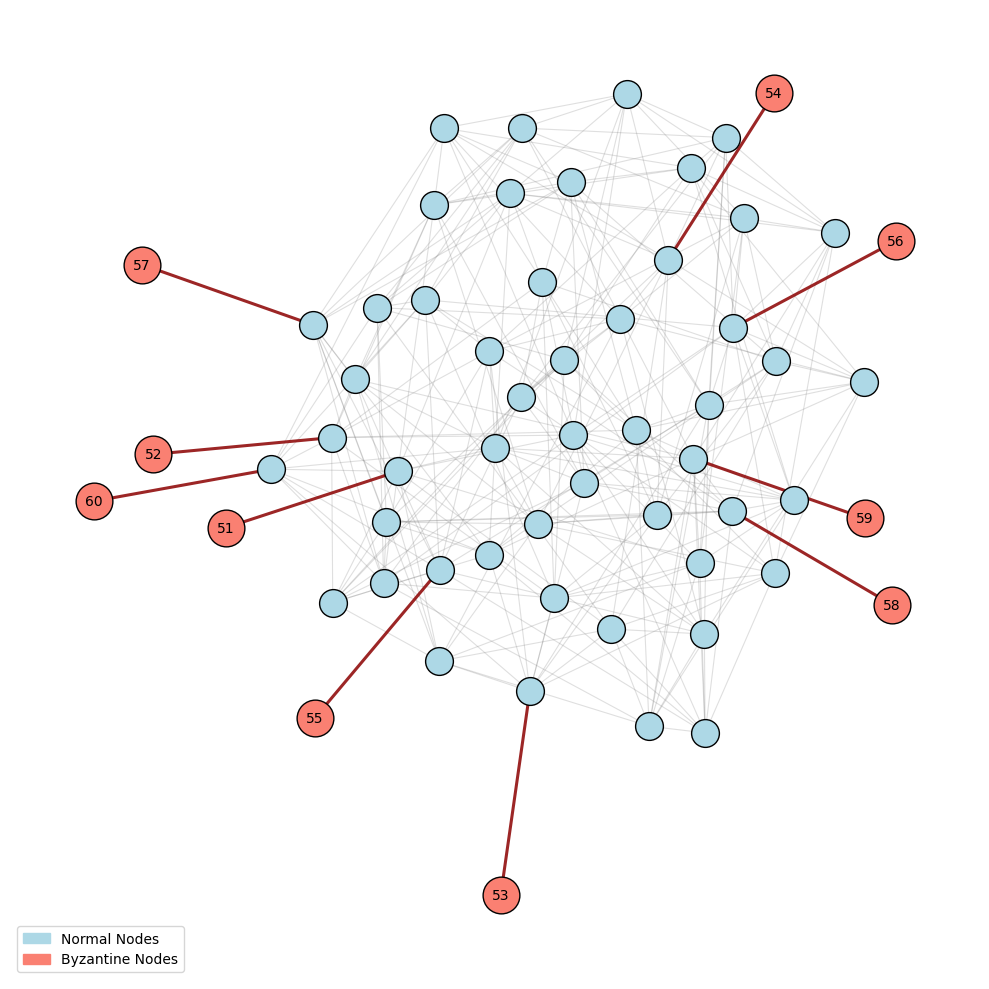

In [2]:
def graph(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    # Huge case
    import networkx as nx

    n = 50
    d = 10

    G_: nx.Graph = nx.random_regular_graph(d, n, seed=42)

    mapping = {i: str(i + 1) for i in range(n)}
    G_ = nx.relabel_nodes(G_, mapping)

    NORMAL_NODES = list(G_.nodes())
    NORMAL_EDGES = list(G_.edges())

    BYZANTINE_NODES = ["51", "52", "53", "54", "55", "56", "57", "58", "59", "60"]
    BYZANTINE_EDGES = [
        ("1", "51"),
        ("2", "52"),
        ("3", "53"),
        ("4", "54"),
        ("5", "55"),
        ("6", "56"),
        ("7", "57"),
        ("8", "58"),
        ("9", "59"),
        ("10", "60"),
    ]

    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig, ax = plt.subplots(figsize=(10, 10))

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    G_normal = G.subgraph(NORMAL_NODES)
    pos_normal = nx.spring_layout(G_normal, seed=15, k=0.5)

    pos: dict[str, npt.NDArray[np.float64]] = dict(pos_normal)

    # Place each Byzantine node slightly outside the normal node it is connected to.
    PUSH = 0.6

    for u, v in BYZANTINE_EDGES:
        p = pos[u]
        r = np.linalg.norm(p)
        if r < 1e-9:
            direction = np.array([1.0, 0.0])
        else:
            direction = p / r

        cand = p + PUSH * direction

        pos[v] = cand

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=NORMAL_EDGES,
        width=0.8,
        alpha=0.25,
        edge_color="gray",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=BYZANTINE_EDGES,
        width=2.2,
        edge_color="#8B0000",
        alpha=0.85,
        style="solid",
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=400,
        edgecolors="black",
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=700,
        edgecolors="black",
        ax=ax,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels={node: node for node in BYZANTINE_NODES},
        font_size=10,
        ax=ax,
    )

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")

    ax.axis("off")
    plt.tight_layout()

    fig.savefig(FIGURE_PATH / "large_scale_graph.pdf", format="pdf")

## (2) Define the behavior of Byzantine nodes

A Byzantine node ignores the states of its neighbors.
Let the state of node $i$ at iteration $t$ be denoted as $x_i(t)$.
Then the update rule for a Byzantine node can be described as:

1. **Keep state constant:**
   $$
   x_i(t + 1) = x_i(t)
   $$

2. **Update state randomly:**
   $$
   x_i(t) \sim \mathcal{U}(a, b)
   $$
   where $\mathcal{U}(a, b)$ denotes a uniform random variable in the range $[a, b]$, which represents the possible values that the Byzantine node can take.

3. **Add perturbation:**
   $$
   x_i(t + 1) = x_i(t) - \alpha \sum_{j \in \mathcal{N}_i} \big(x_i(t) - x_j(t)\big) + \eta_i(t)
   $$
   where $\eta_i(t)$ is an interference term (noise) that can be modeled as either deterministic or stochastic, e.g.
   $$
   \eta_i(t) \sim \mathcal{U}(a, b).
   $$
   This form represents a Byzantine node that actively injects perturbations into its state to disrupt the consensus process.

In [3]:
def byzantine_node(
    name: str, n_state: int, alpha: float, n_iter: int, attacker_model: str
) -> npt.NDArray[np.float64]:
    from numpy import zeros
    from numpy.random import seed, uniform
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node

    if attacker_model == "extreme_constant":
        x[0] = uniform(100000, 110000, n_state)

        for k in range(n_iter - 1):
            _ = nh.laplacian(x[k])
            x[k + 1] = x[k]

    elif attacker_model == "random":
        for k in range(n_iter - 1):
            to_send = {j: uniform(-100.0, 100.0, n_state) for j in nh.neighbors}
            _ = nh.neighborwise_exchange(to_send)

    else:
        raise ValueError(f"Unknown attacker model: {attacker_model}")

    return x

# 3. Execute a standard consensus algorithm

In our system, the state of each node is updated using a consensus iteration. Let $x_i(t) \in \mathbb{R}^d$ denote the state of node $i$ at iteration $t$, where $d$ is the dimension of the state.
The consensus update is given by

$$
x_i(t + 1) = x_i(t) - \alpha \sum_{j \in \mathcal{N}_i}(x_i(t) - x_j(t))
$$

where $\mathcal{N}_i$ is the set of neighbors of node $i$, and $\alpha > 0$ is the step size.

## (1) Run the algorithm

In [4]:
def baseline_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        x[k + 1] = x[k] - nh.laplacian(x[k]) * alpha

    return x


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        baseline_results = {
            i: pool.apply_async(baseline_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, ATTACKER_MODEL)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        baseline_data = {i: result.get() for i, result in baseline_results.items()}
        byzantine_data = {i: result.get() for i, result in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:46623
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '9' joined graph 'default' from 10.20.13.39:46069.
INFO:topolink.graph:Node '26' joined graph 'default' from 10.20.13.39:46307.
INFO:topolink.graph:Node '59' joined graph 'default' from 10.20.13.39:45109.
INFO:topolink.graph:Node '8' joined graph 'default' from 10.20.13.39:45955.
INFO:topolink.graph:Node '51' joined graph 'default' from 10.20.13.39:45039.
INFO:topolink.graph:Node '29' joined graph 'default' from 10.20.13.39:44827.
INFO:topolink.graph:Node '54' joined graph 'default' from 10.20.13.39:45599.
INFO:topolink.graph:Node '33' joined graph 'default' from 10.20.13.39:45055.
INFO:topolink.graph:Node '19' joined graph 'default' from 10.20.13.39:45163.
INFO:topolink.graph:Node '38' joined graph 'default' from 10.20.13.39:45035.
INFO:topolink.graph:Node '60' joined graph 'default' from 10.20.13.39:44883.
INFO:topolink.graph:

## (2) Visualize the Results

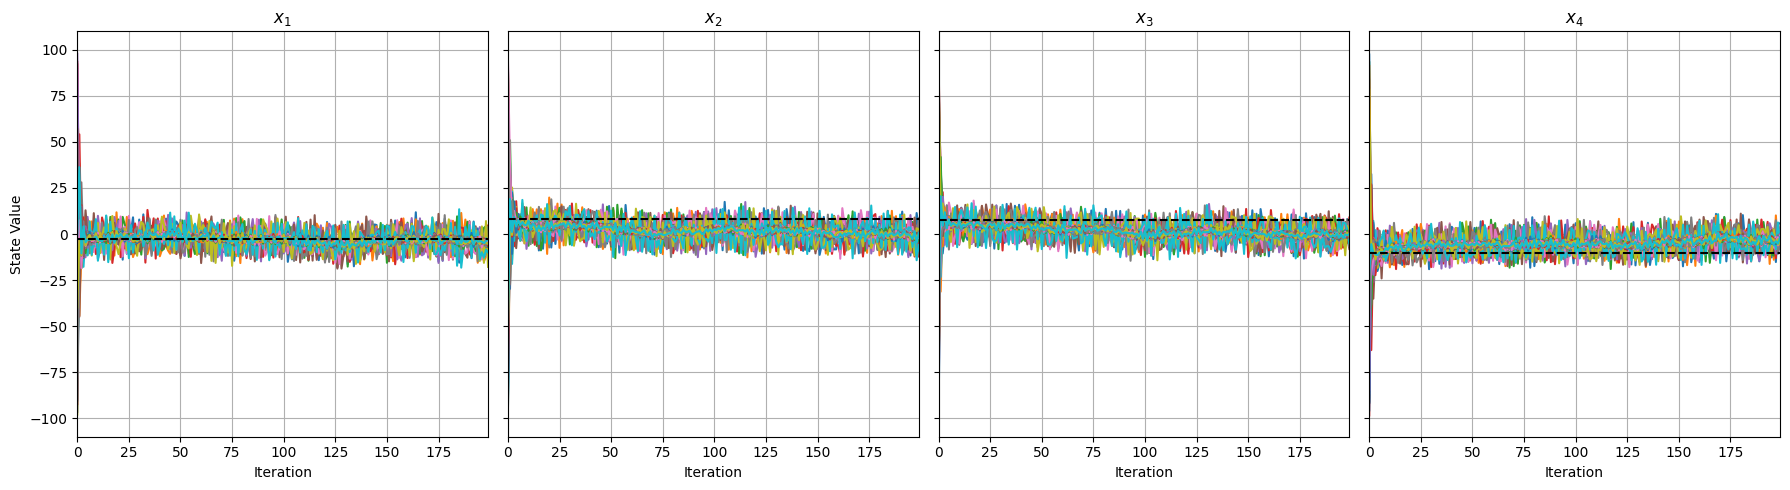

In [5]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = baseline_data[i]
        for j in range(N_STATE):
            axes[j].plot(states[:, j])

    initial_states = [baseline_data[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

    for j in range(N_STATE):
        axes[j].axhline(mean_states[j], color="k", linestyle="--")

    for j in range(N_STATE):
        axes[j].set_xlabel("Iteration")
        axes[j].set_xlim(0, N_ITER - 1)
        axes[j].set_title(f"$x_{j + 1}$")
        axes[j].grid()

    axes[0].set_ylabel("State Value")

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "standard_states.pdf", format="pdf")

# 4. Expressive reputation-based consensus algorithm
---
## Loss function

1. **Quasi geometric median loss:**

   For each node $i$ and each neighbor $j \in \mathcal{N}_i$, we define the loss as

   $$
   l_{ij}(t) = \sum_{v \in \mathcal{N}_i} \frac{\| x_j(t) - x_v(t) \|}{d_i},
   $$

   where $x_j(t)$ denotes the state received from neighbor $j$ at iteration $t$, $\mathcal{N}_i$ is the set of neighbors of node $i$, and $d_i = |\mathcal{N}_i|$ denotes its degree.

   This loss quantifies the local geometric inconsistency between neighbor $j$ and the remaining neighbors of node $i$. It can be viewed as a **quasi–geometric median** measure, since it approximates the notion of the **geometric median**, defined as

   $$
   {gm}_i = \arg\min_x \sum_{v \in \mathcal{N}_i} \|x - x_v\|.
   $$

   Neighbors closer to this geometric median yield smaller losses, while outliers or Byzantine neighbors exhibit larger ones.

2. **Geometric median loss:**

   Also, we define the **geometric median loss**, which directly measures the distance of each neighbor's state to the true geometric median:

   $$
   l_{ij}(t) = \| x_j(t) - {gm}_{i}(t) \|,
   $$

   where 
   $$
   {gm}_{i}(t) = \arg\min_x \sum_{v \in \mathcal{N}_i} \| x - x_v(t) \|
   $$
   is the **geometric median** of node $i$’s neighbors at iteration $t$.

   Computing the geometric median at each iteration requires solving a non-smooth convex optimization problem, which can be computationally expensive compared to the quasi geometric median or coordinate-wise median.

3. **Coordinate-wise median loss:**

   Alternatively, we define a **coordinate-wise median loss**, which quantifies the deviation of each neighbor's state from the coordinate-wise median of all neighbors:

   $$
   l_{ij}(t) = \| x_j(t) - {cm}_{i}(t) \|_1,
   $$

   where 
   $$
   {cm}_{i}(t) = \arg\min_x \sum_{v \in \mathcal{N}_i} \| x - x_v(t) \|_1
   $$
   denotes the coordinate-wise median of node $i$’s neighbors at iteration $t$.

   Note that since the coordinate-wise median is computed independently across coordinates, ${cm}_i(t)$ is **not necessarily a convex combination of the neighbors and may even lie outside their convex hull**.

4. **Mean loss:**

   We define the **mean loss**, which measures each neighbor’s deviation from the average of all neighbor states:

   $$
   l_{ij}(t) = \| x_j(t) - m_{i}(t) \|
   $$

   where
   $$
   m_{i}(t) = \frac{1}{d_i} \sum_{v \in \mathcal{N}_i} x_v(t)
   $$

   denotes the mean state of node $i$'s neighbors at iteration $t$.

   Although the mean is theoretically non-robust and highly sensitive to outliers or Byzantine neighbors, its empirical performance in our setting turns out to be **surprisingly strong**.

5. **Trimmed-mean loss:**

   We define the **trimmed-mean loss**, which mitigates the influence of extreme neighbor values by averaging only the central subset of neighbor states:

   $$
   l_{ij}(t) = \| x_j(t) - tm_i(t) \|
   $$

   Here $tm_i(t)$ denotes the **coordinate-wise trimmed mean**. For each coordinate $k$, we remove the largest $f$ and smallest $f$ neighbor values and average the remaining ones:

   $$
   tm_{i,k}(t) = \frac{1}{d_i - 2f} \sum_{v \in S_{i,k}(t)} x_{v,k}(t)
   $$

   where $S_{i,k}(t)$ is the set of neighbors whose $k$-th coordinate lies in the central $d_i - 2f$ range after discarding the $f$ largest and $f$ smallest values.

   > **Practical consideration:** This loss requires an additional hyperparameter $f$, which implicitly assumes prior knowledge of the number of extreme or faulty neighbors. Such information is typically unavailable in practice, making the choice of $f$ unrealistic. Therefore, the trimmed-mean loss is included for conceptual completeness but is **not used in practice**.

---

## Cumulative loss

Using **instantaneous loss only** for weight assignment is insufficient in Byzantine-resilient settings, as it fails to capture the long-term impact of **persistent but small-magnitude adversarial perturbations**.
A Byzantine node may inject carefully crafted deviations that remain below detection thresholds at each iteration, yet gradually cumulate and lead to a significant bias in the aggregated estimate. Relying solely on instantaneous loss would therefore render the system blind to such slow but systematic attacks.

Conversely, **retaining full historical memory** is also undesirable in adversarial and nonstationary environments.
A malicious node may behave honestly for an extended period to cumulate trust and then exploit this long-term memory to exert disproportionate influence during an attack phase.
Moreover, even when all neighbors are honest and eventually reach consensus, their cumulative losses are typically different due to early-stage discrepancies and local noise, which violates the goal of **treating all honest nodes equally**.

These observations indicate that an effective defense against Byzantine behavior requires a **finite-memory loss mechanism** that can cumulate evidence over time while gradually forgetting outdated information.

#### Option I: Exponentially decayed

A first approach is to adopt a **decayed cumulative loss** with a forgetting factor $\lambda \in (0,1]$:
$$
L_{ij}(t) = \lambda\, L_{ij}(t - 1) + l_{ij}(t).
$$

This formulation emphasizes recent observations while gradually discounting older information. By tuning $\lambda$, the effective memory length can be adjusted, interpolating between the instantaneous-loss regime ($\lambda = 0$) and long-term averaging.

#### Option II: Moving-horizon

An alternative approach is to impose an explicit **moving horizon** of length $H$, which restricts the loss to the most recent $H$ observations and **discards all earlier history**. The moving-horizon (windowed) cumulative loss is defined as
$$
L_{ij}(t) = \sum_{\tau=\max(0,t-H+1)}^{t} l_{ij}(\tau).
$$

For online implementation, $L^{(H)}_{ij}(t)$ admits the recursion
$$
L_{ij}(t) = L_{ij}(t-1) + l_{ij}(t) - l_{ij}(t-H),
$$
where $l_{ij}(s)=0$ for $s < 0$.

This moving-horizon formulation provides a strict finite-memory mechanism: it cumulates evidence over the last $H$ rounds to detect persistent small attacks, while ensuring that any behavior prior to the window has no influence on the current weights.

---

## Probabilistic selection via loss normalization

In multi-class classification and attention mechanisms, **normalization mappings** are used to transform a vector of real-valued scores into a probability distribution over classes or tokens. Softmax is the most widely used mapping, while Sparsemax and Entmax have been proposed to address its limitations in terms of sparsity and interpretability.

### Option I: Softmax

**Softmax** maps an input vector to a strictly positive probability distribution by exponentiation and normalization:

$$
\operatorname{softmax}(z_i) = \frac{\exp(z_i)}{\sum_j \exp(z_j)}
$$

**Properties:**
- Produces a **dense probability distribution** (all entries are strictly positive)
- Smooth and fully differentiable, making it well-suited for gradient-based optimization

**Limitations:**
- Cannot produce exact zeros
- Often yields diffuse attention distributions, reducing interpretability

### Option II: Sparsemax

**Sparsemax** is defined as the Euclidean projection of the input vector onto the probability simplex:

$$
\operatorname{sparsemax}(z) = \arg\min_{p \in \Delta} \|p - z\|^2
$$

where the probability simplex is defined as:

$$
\Delta = \left\{ p \in \mathbb{R}^K \mid p \ge 0,\ \sum_i p_i = 1 \right\}
$$

**Properties:**
- Produces **sparse probability distributions**, with some components exactly equal to zero
- Improves interpretability, especially in attention-based models
- Less sensitive to small score variations than Softmax

**Drawbacks:**
- Gradients may be discontinuous at the boundary of the simplex

### Option III: Entmax

**Entmax** generalizes Softmax and Sparsemax by introducing a parameterized entropy based on Tsallis entropy, controlled by $\alpha$:

$$
\operatorname{\alpha-entmax}(z) = \arg\max_{p \in \Delta} \left( p^\top z + H_\alpha(p) \right)
$$

where the Tsallis $\alpha$-entropy is defined as:

$$
H_\alpha(p) =
\begin{cases}
\displaystyle \frac{1}{\alpha(\alpha - 1)} \left( 1 - \sum_i p_i^\alpha \right), & \alpha \neq 1 \\\\
\displaystyle -\sum_i p_i \log p_i, & \alpha = 1
\end{cases}
$$

Special cases:
- $\alpha = 1$: equivalent to Softmax  
- $\alpha = 1.5$: a commonly used setting with a **closed-form solution**, offering a practical balance between smoothness and sparsity  
- $\alpha = 2$: equivalent to Sparsemax  

**Properties:**
- Allows **continuous control of sparsity** via the parameter $\alpha$
- Provides a flexible trade-off between smoothness and sparsity

### Comparison Summary

<div align="center">

| Method    | Sparse Output | Tunable Sparsity | Interpretability |
|-----------|---------------|------------------|------------------|
| Softmax   | No            | No               | Low              |
| Sparsemax | Yes           | No               | High             |
| Entmax    | Yes           | Yes              | High             |

</div>

In summary, Softmax prioritizes smoothness and numerical stability, Sparsemax emphasizes sparsity and interpretability, and Entmax provides a unified framework that interpolates between the two.

---

## The proposed algorithm

### Initialization

For each node $i$:

- Initialize the local state randomly:  
  $$
  x_i(0) \sim \text{Random}.
  $$  

- Initialize the cumulative loss:  
  $$
  L_{ij}(0) = 0, \quad \forall j \in \mathcal{N}_i.
  $$  


### Iterative Update (for each time step $t = 0,1,2,\dots$)

For each node $i$, repeat:

1. Exchange the current state $x_i(t)$ with neighbors and receive  
   $$
   x_j(t), \quad \forall j \in \mathcal{N}_i.
   $$  

2. Evaluate neighbors via biased estimate

   Observe a biased estimate of the honest neighbors’ average (e.g., via the geometric median, coordinate-wise median, or trimmed mean)
   $$
   y_i(t) = \mathcal{B}_i\big(\{x_j(t)\}_{j \in \mathcal{N}_i}\big),
   $$
   and then evaluate the corresponding losses
   $$
   l_{ij}(t) = \ell\big(x_j(t), y_i(t)\big), \quad \forall j \in \mathcal{N}_i
   $$

3. Update the cumulative loss

   - **Exponentially decayed**:
     $$
     L_{ij}(t) = \lambda\,L_{ij}(t-1) + l_{ij}(t), \qquad j\in\mathcal{N_i}.
     $$

   - **Moving-horizon**:
     $$
     L_{ij}(t) = L_{ij}(t-1) + l_{ij}(t) - l_{ij}(t-H), \qquad j\in\mathcal{N_i},
     $$
     where $l_{ij}(s)=0$ for $s < 0$.

3. Normalize the cumulative loss to the probability simplex

   Define the vectors
   $$
   L_i(t) = \big[L_{ij}(t)\big]_{j\in\mathcal N_i}, \qquad p_i(t) = \big[p_{ij}(t)\big]_{j\in\mathcal N_i}.
   $$

   Compute the probability distribution by mapping the cumulative losses onto the probability simplex:
   - **Smooth, strictly positive**:
     $$
     p_i(t+1) = \operatorname{softmax}\!\big(-\eta L_i(t+1)\big).
     $$

   - **Sparsity-inducing**:
     $$
     p_i(t+1) = \operatorname{sparsemax}\!\big(-\eta L_i(t+1)\big).
     $$

   - **Intermediate sparsity**:
     $$
     p_i(t+1) = \operatorname{1.5-entmax}\!\big(-\eta L_i(t+1)\big).
     $$

   Here $\eta$ controls the sensitivity of the probability assignment to the cumulative losses.

4. Compute the aggregated prediction and update the local state  
   $$
   x_i(t+1) = (1 - \alpha) x_i(t) + \alpha \sum_{j \in \mathcal{N}_i} p_{ij}(t+1)\, x_j(t),
   $$
   where $\alpha \in (0,1)$ balances the historical state and the aggregated estimate.

---

### (1) Run the algorithm

In [6]:
def arepc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc import ARepC

    agent = ARepC(nh, alpha, eta=0.001, loss_func="cmed", normalization="sparsemax")

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        x[k + 1] = agent.weighted_mix(x[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return x, reps


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        arepc_results = {
            i: pool.apply_async(arepc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, ATTACKER_MODEL)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        arepc_data = {i: node.get() for i, node in arepc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:44717
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '48' joined graph 'default' from 10.20.13.39:45161.
INFO:topolink.graph:Node '51' joined graph 'default' from 10.20.13.39:46115.
INFO:topolink.graph:Node '3' joined graph 'default' from 10.20.13.39:44803.
INFO:topolink.graph:Node '34' joined graph 'default' from 10.20.13.39:45065.
INFO:topolink.graph:Node '7' joined graph 'default' from 10.20.13.39:45079.
INFO:topolink.graph:Node '31' joined graph 'default' from 10.20.13.39:45673.
INFO:topolink.graph:Node '56' joined graph 'default' from 10.20.13.39:45389.
INFO:topolink.graph:Node '53' joined graph 'default' from 10.20.13.39:46659.
INFO:topolink.graph:Node '40' joined graph 'default' from 10.20.13.39:45395.
INFO:topolink.graph:Node '52' joined graph 'default' from 10.20.13.39:45355.
INFO:topolink.graph:Node '5' joined graph 'default' from 10.20.13.39:44723.
INFO:topolink.graph:N

## (2) Visualize the Results

### 1. State evolution for each normal node

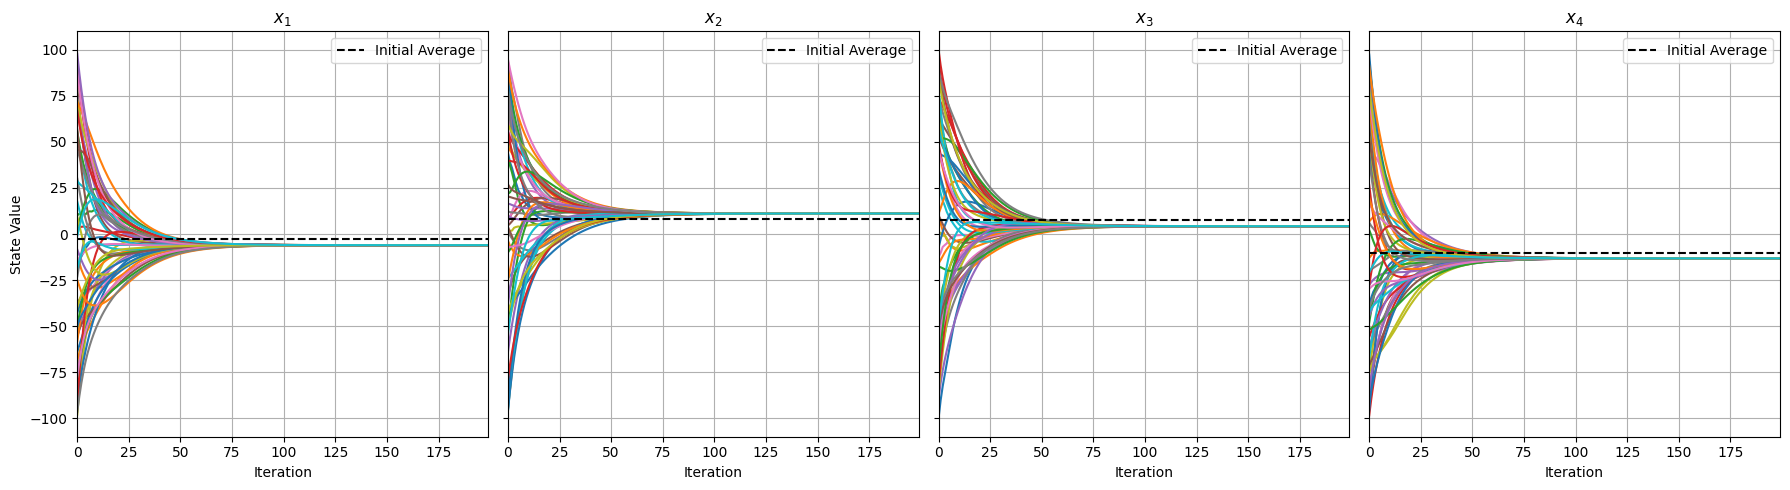

In [ ]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    arepc_states = {i: arepc_data[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = arepc_states[i]
        for j in range(N_STATE):
            axes[j].plot(states[:, j])

    initial_states = [arepc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

    for j in range(N_STATE):
        axes[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Initial Average"
        )

    for j in range(N_STATE):
        axes[j].set_xlabel("Iteration")
        axes[j].set_xlim(0, N_ITER - 1)
        axes[j].set_title(f"$x_{j + 1}$")
        axes[j].grid()
        axes[j].legend()

    axes[0].set_ylabel("State Value")

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "arepc_states.pdf", format="pdf")

### 2. Weight evolution for each node

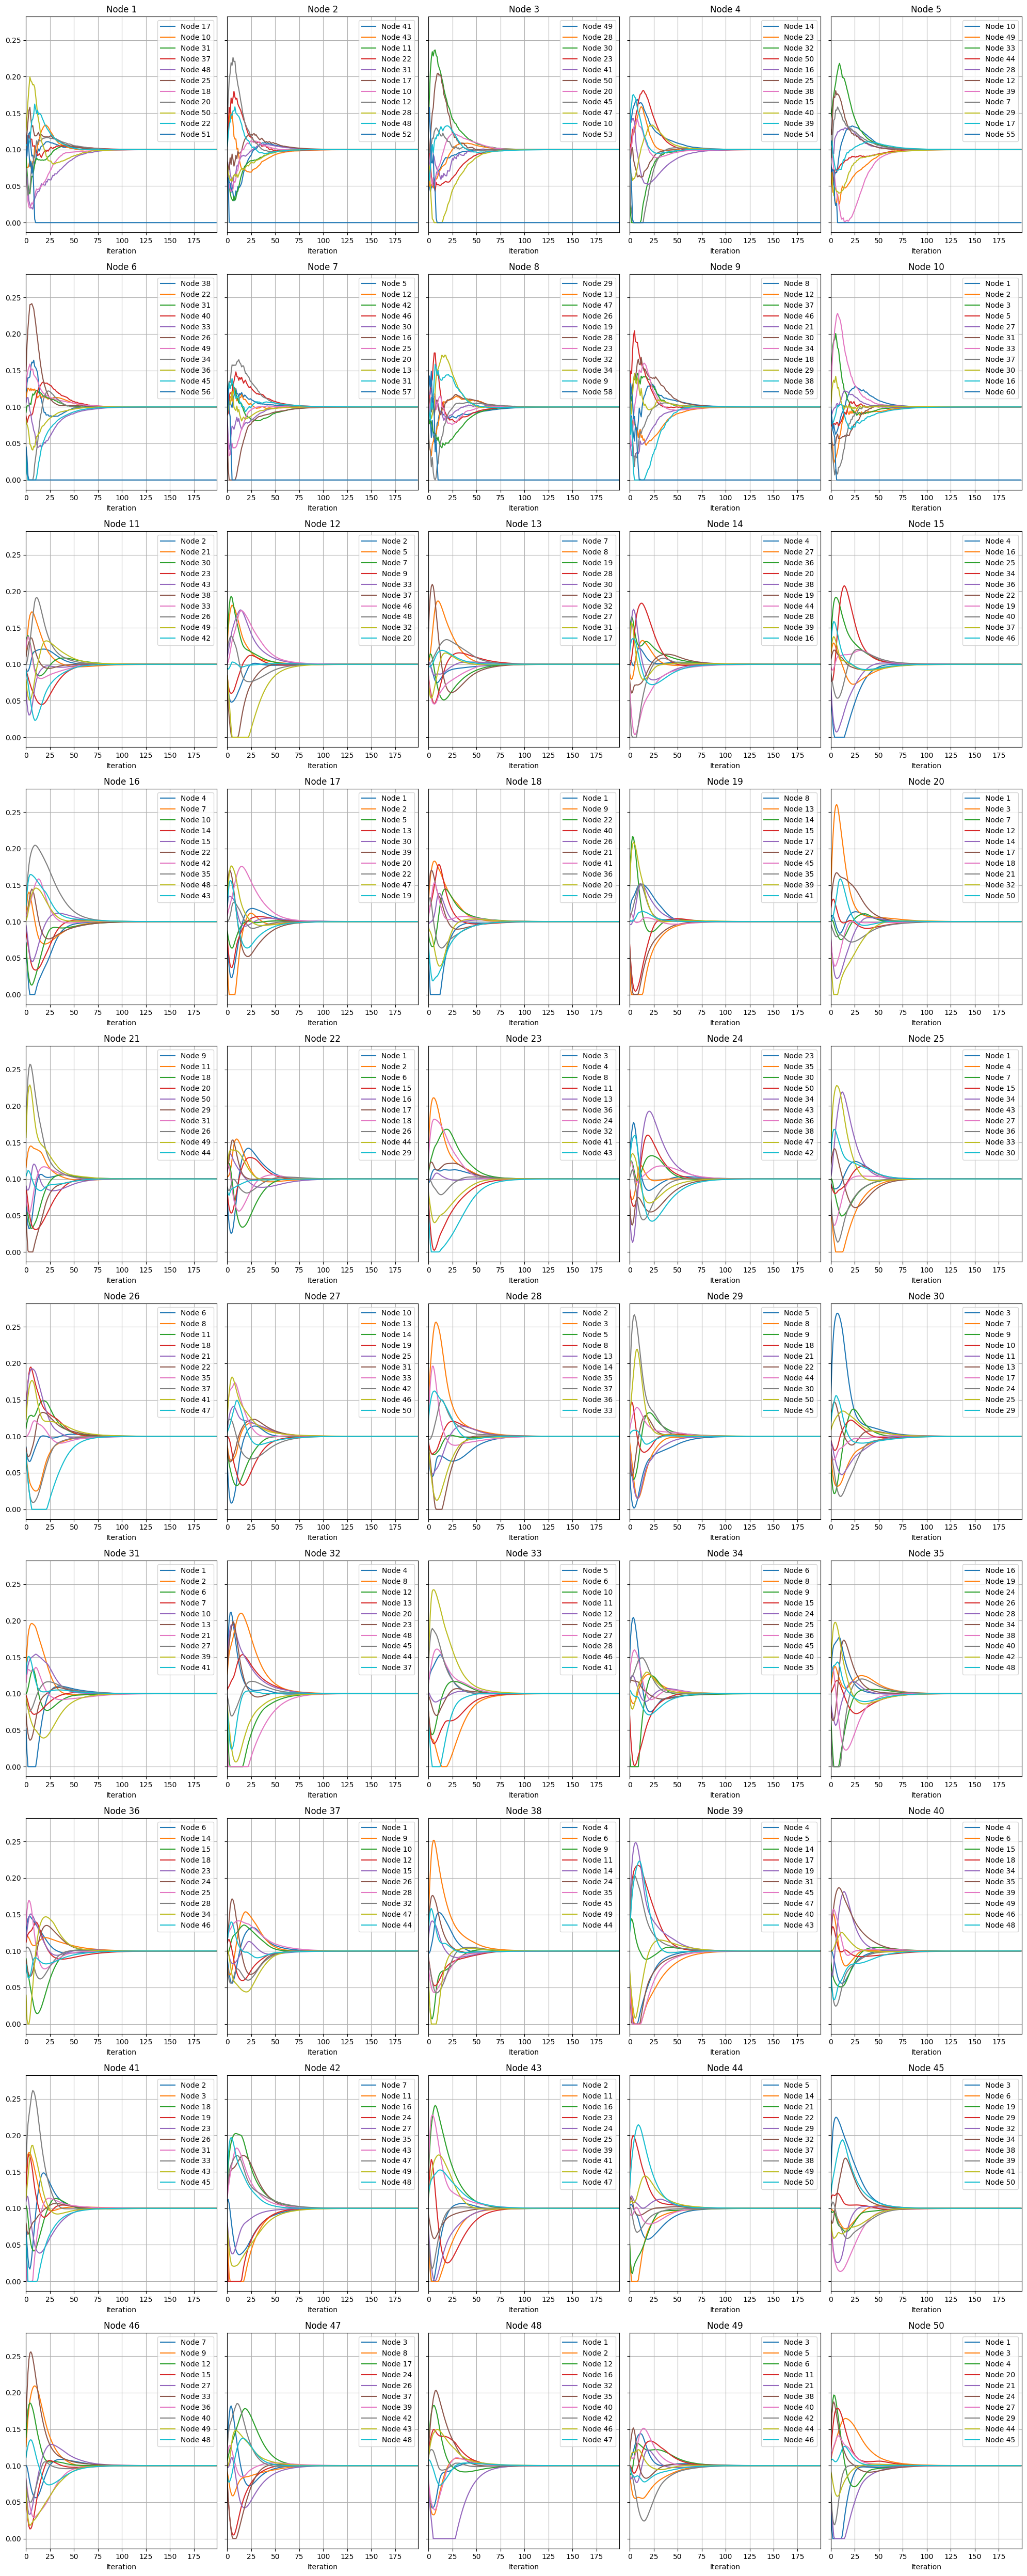

In [8]:
if __name__ == "__main__":
    n_cols = 5
    n_rows = (N_NORMAL + n_cols - 1) // n_cols
    axes: np.ndarray
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True)

    arepc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes.flatten()):
        ax: maxes.Axes
        reps_for_i = arepc_reps[i]
        for j in reps_for_i:
            ax.plot(reps_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    fig.tight_layout()

### 3. Representative nodes

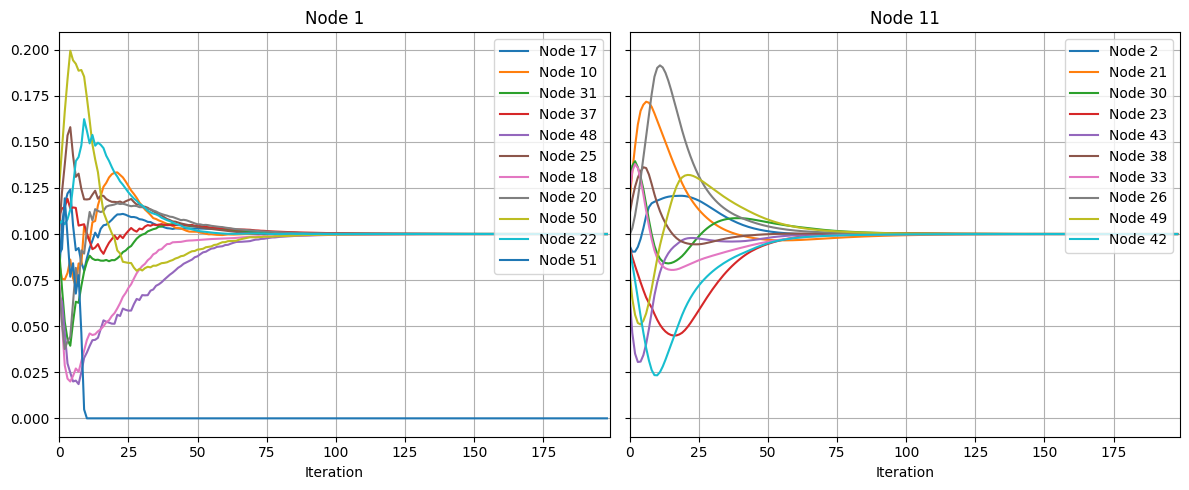

In [9]:
if __name__ == "__main__":
    axes: np.ndarray
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    representative_nodes = ["1", "11"]

    for i, ax in zip(representative_nodes, axes.flatten()):
        ax: maxes.Axes
        reps_for_i = arepc_reps[i]
        for j in reps_for_i:
            ax.plot(reps_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend(loc="upper right")
        ax.grid()

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "arepc_reputations.pdf", format="pdf")

# 5. Reputation-based consensus

1. Exchange the current state $x_i(t)$ with neighbors and receive  
   $$
   x_j(t), \quad \forall j \in \mathcal{N}_i.
   $$

2. Compute reputation

   Each node $i$ first estimates the preliminary reputation of its neighbor $j \in \mathcal{N}_i$ based on their state difference:
   $$
   \tilde{c}_{ij}(t) =
   \begin{cases}
   1 - \sum_{v \in \mathcal{N}_i} \frac{\| x_j(t) - x_v(t) \|}{| \mathcal{N}_i |}, & j \in \mathcal{N}_i, \\[6pt]
   0, & \text{otherwise.}
   \end{cases}
   $$
   This formulation penalizes neighbors whose states significantly deviate from others in $\mathcal{N}_i$, thereby reducing their reputational weight.

3. Normalize reputation

   To ensure comparability across different neighbors, the reputations are normalized within the neighborhood:
   $$
   \tilde{\tilde{c}}_{ij}(t) =
   \begin{cases}
   \dfrac{\tilde{c}_{ij}(t) - \min\nolimits_{v \in \mathcal{N}_i}^f \tilde{c}_{iv}(t)}
   {\max\nolimits_{v \in \mathcal{N}_i} \tilde{c}_{iv}(t) - \min\nolimits_{v \in \mathcal{N}_i}^f \tilde{c}_{iv}(t)},
   & \text{if not all } \tilde{c}_{iv}(t) \text{ are equal}, \\[10pt]
   1, & \text{otherwise.}
   \end{cases}
   $$

4. Trim reputation with confidence $\epsilon$

   To prevent reputations from vanishing and to maintain minimal trust even for low-confidence neighbors, a confidence-based lower bound is applied:
   $$
   c_{ij}(t) =
   \begin{cases}
   \tilde{\tilde{c}}_{ij}(t), & \text{if} \quad \tilde{\tilde{c}}_{ij}(t) > 0, \\[6pt]
   \epsilon^k, & \text{otherwise.}
   \end{cases}
   $$

   Here, $\min^f$ denotes a generalized order statistic defined as follows: it is obtained by first removing duplicates from the multiset $\{\tilde{c}_{iv}^{(k+1)} : v \in \mathcal{N}_i\}$ and then selecting the $f$-th smallest distinct value.
   If this value happens to coincide with the maximum element of the multiset,  the $(f-1)$-th smallest distinct value is used instead.

5. Aggregate states

   Finally, each node updates its state by aggregating information from its neighbors, weighted by the trimmed reputations:
   $$
   x_i(t+1) = x_i(t) - \alpha \frac{\sum_{j \in \mathcal{N}_i} c_{ij}(t) \big( x_i(t) - x_j(t) \big)}{\sum_{j \in \mathcal{N}_i} c_{ij}(t)}.
   $$
   This adaptive aggregation allows nodes to gradually adjust their states toward more reputable neighbors while mitigating the influence of unreliable ones.

---

## (1) Run the algorithm

In [10]:
def repc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import RepC

    agent = RepC(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return states, reps


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        repc_results = {
            i: pool.apply_async(repc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, ATTACKER_MODEL)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        repc_data = {i: node.get() for i, node in repc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:46051
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '12' joined graph 'default' from 10.20.13.39:46445.
INFO:topolink.graph:Node '55' joined graph 'default' from 10.20.13.39:45459.
INFO:topolink.graph:Node '45' joined graph 'default' from 10.20.13.39:45463.
INFO:topolink.graph:Node '17' joined graph 'default' from 10.20.13.39:46447.
INFO:topolink.graph:Node '34' joined graph 'default' from 10.20.13.39:44991.
INFO:topolink.graph:Node '37' joined graph 'default' from 10.20.13.39:45557.
INFO:topolink.graph:Node '46' joined graph 'default' from 10.20.13.39:46605.
INFO:topolink.graph:Node '11' joined graph 'default' from 10.20.13.39:44923.
INFO:topolink.graph:Node '26' joined graph 'default' from 10.20.13.39:45959.
INFO:topolink.graph:Node '38' joined graph 'default' from 10.20.13.39:44873.
INFO:topolink.graph:Node '44' joined graph 'default' from 10.20.13.39:45331.
INFO:topolink.grap

## (2) Visualize the Results

### 1. State evolution for each normal node

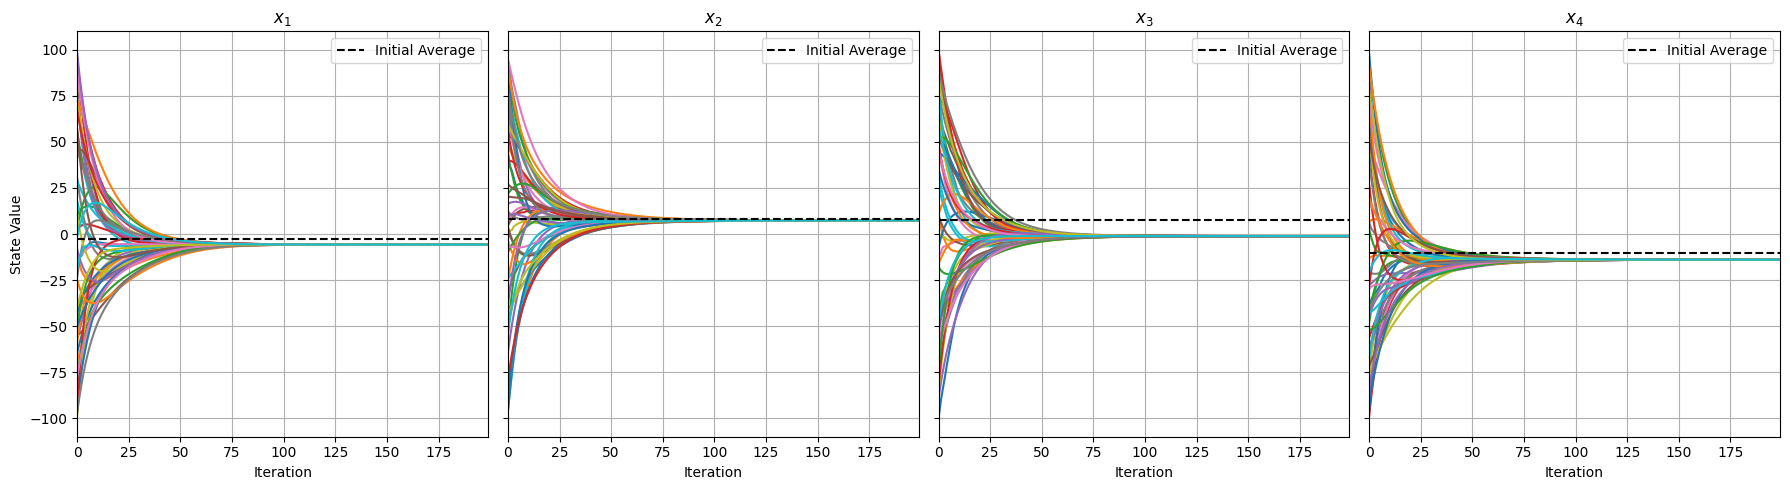

In [18]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    repc_states = {i: repc_data[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = repc_states[i]
        for j in range(N_STATE):
            axes[j].plot(states[:, j])

    initial_states = [repc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        axes[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Initial Average"
        )

    for j in range(N_STATE):
        axes[j].set_xlabel("Iteration")
        axes[j].set_xlim(0, N_ITER - 1)
        axes[j].set_title(f"$x_{j + 1}$")
        axes[j].grid()
        axes[j].legend()

    axes[0].set_ylabel("State Value")

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "repc_states.pdf", format="pdf")

### 2. Weight evolution for each node

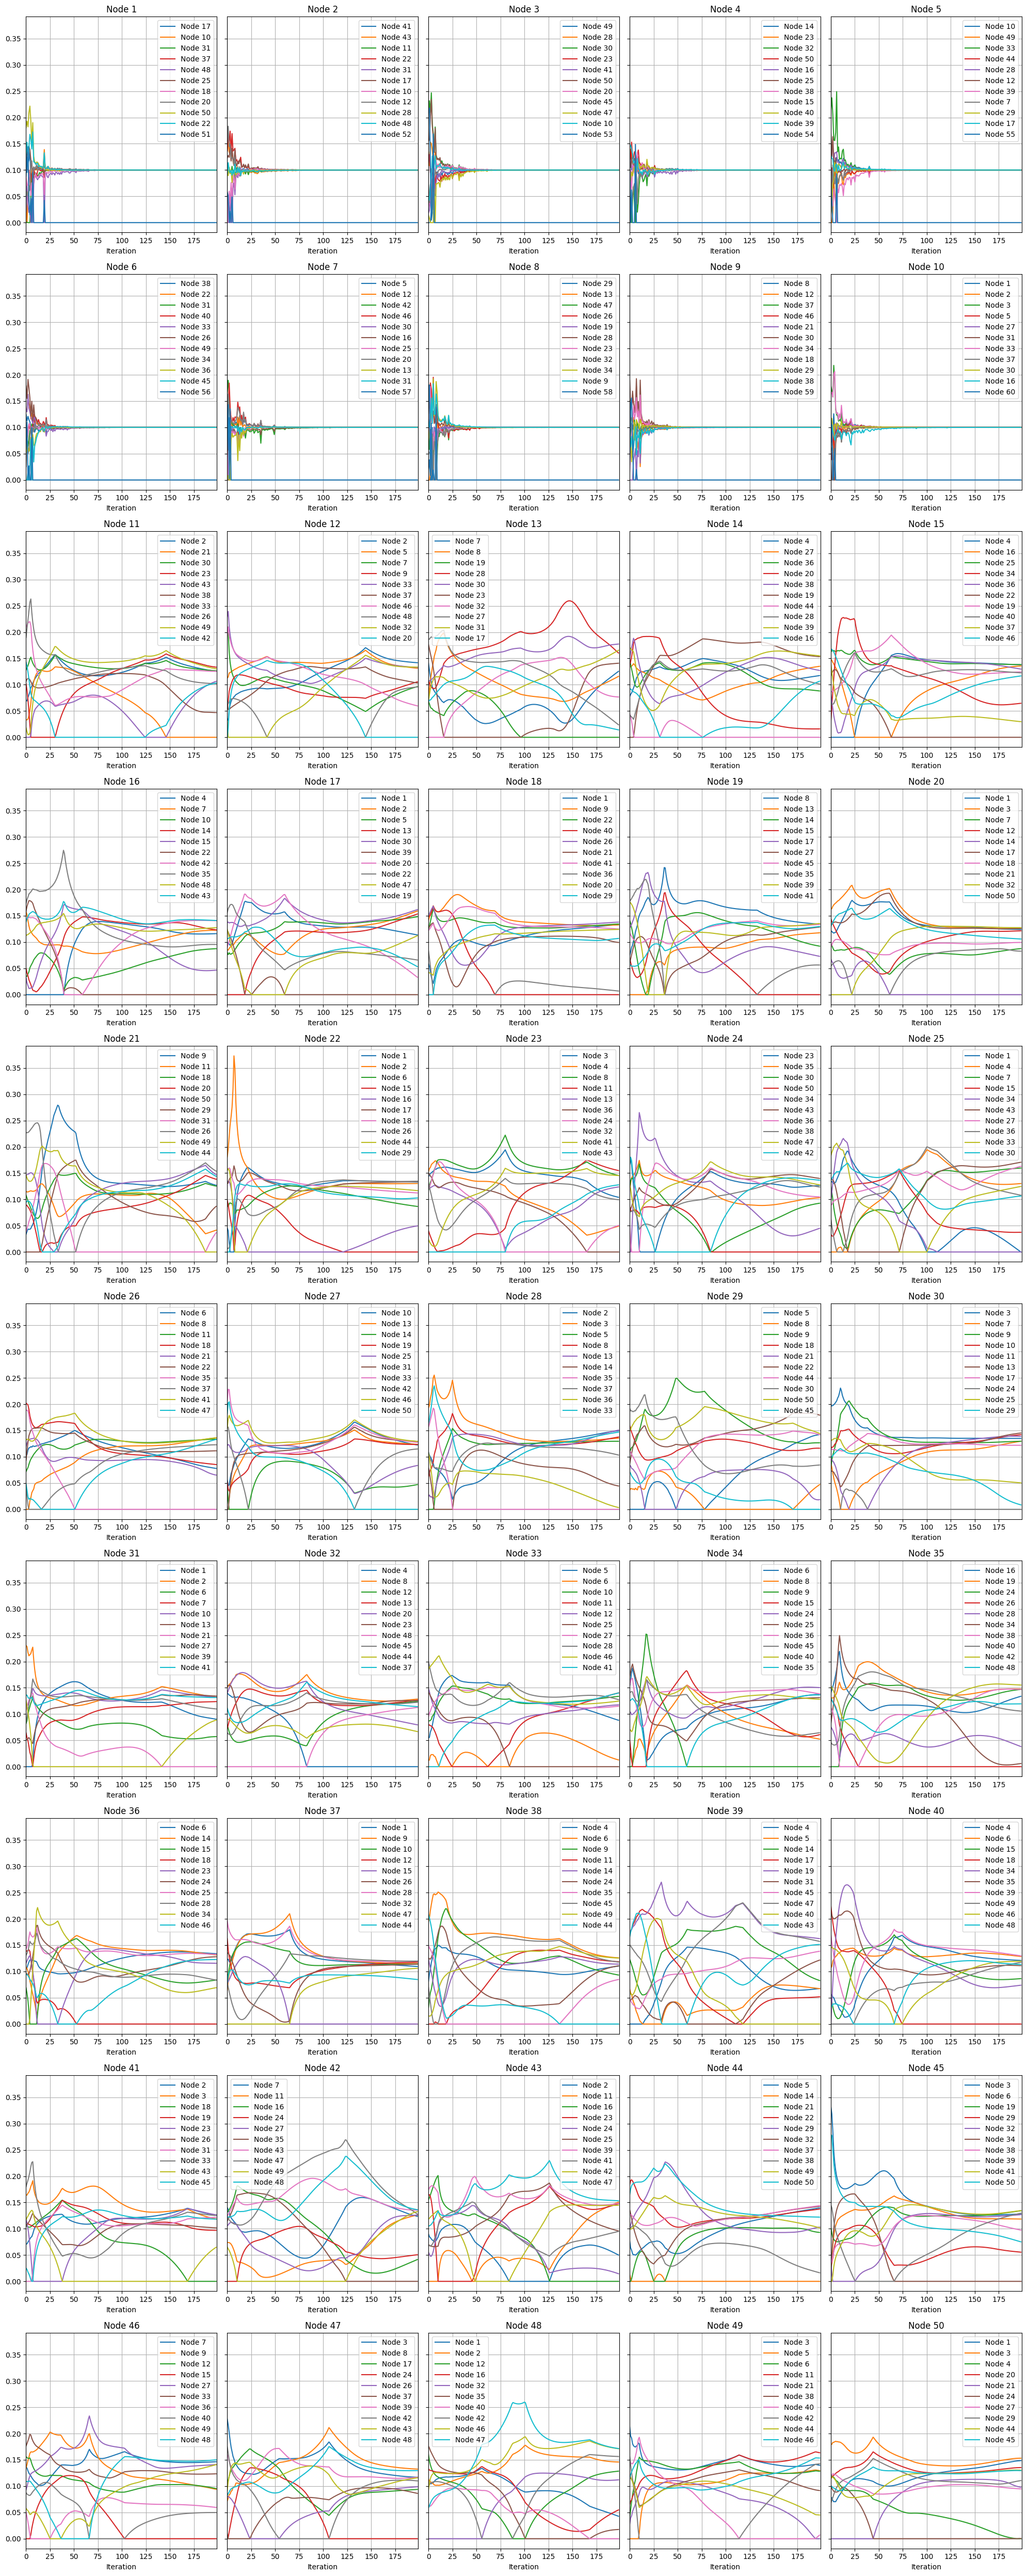

In [12]:
if __name__ == "__main__":
    n_cols = 5
    n_rows = (N_NORMAL + n_cols - 1) // n_cols
    axes: np.ndarray
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True)

    repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes.flatten()):
        ax: maxes.Axes
        reps_for_i = repc_reps[i]
        for j in reps_for_i:
            ax.plot(reps_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    fig.tight_layout()

### 3. Representative nodes

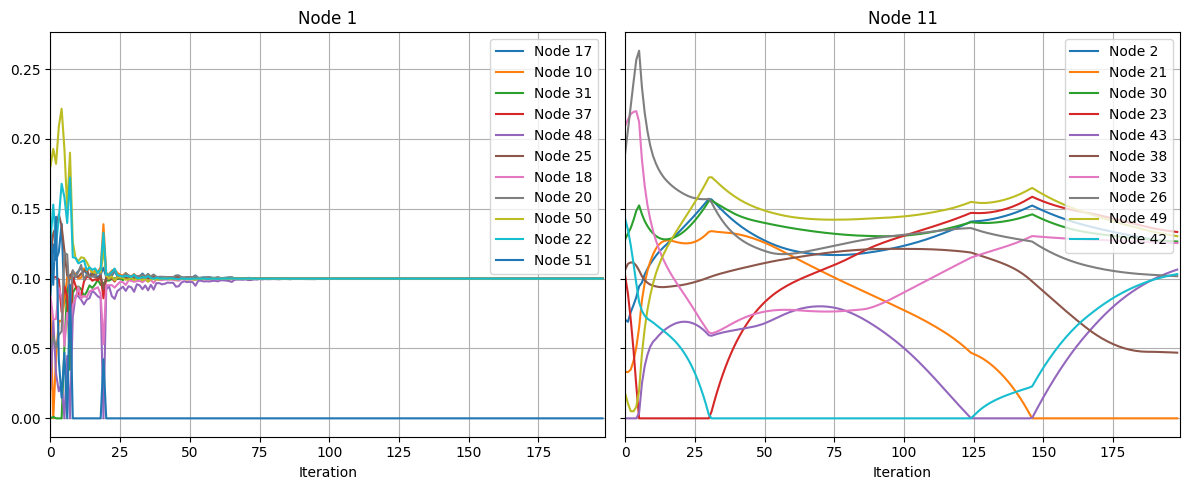

In [13]:
if __name__ == "__main__":
    axes: np.ndarray
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    representative_nodes = ["1", "11"]

    for i, ax in zip(representative_nodes, axes.flatten()):
        ax: maxes.Axes
        reps_for_i = repc_reps[i]
        for j in reps_for_i:
            ax.plot(reps_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend(loc="upper right")
        ax.grid()

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "repc_reputations.pdf", format="pdf")

# 6. W-MSR algorithm

1. Exchange the current state

   Each node $i$ broadcasts its current state and receives the states of its neighbors:
   $$
   x_j(t), \quad \forall j \in \mathcal{N}_i.
   $$

2. Compute neighbor trimmed mean (W-MSR)

   Given a resilience parameter $f \in \mathbb{Z}_{\ge 0}$, node $i$ sorts the received neighbor states
   $\{x_j(t) : j \in \mathcal{N}_i\}$ and removes
   - up to $f$ largest values, and
   - up to $f$ smallest values.

   Let $\mathcal{N}_i^{(k)} \subseteq \mathcal{N}_i$ denote the remaining neighbor index set after trimming, and define the trimmed mean
   $$
   \bar{x}_{i,\mathrm{trim}}(t) = \frac{1}{|\mathcal{N}_i|} \sum_{j \in \mathcal{N}_i} x_j(t).
   $$

3. Update local state

   Node $i$ updates its state by mixing its local value and the neighbor trimmed mean:
   $$
   x_i(t+1) = (1-\alpha)\,x_i(t) + \alpha\,\bar{x}_{i,\mathrm{trim}}(t),
   $$
   where $\alpha \in (0,1]$.

---

## (1) Run the algorithm

In [14]:
def wmsr_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import WMSR

    agent = WMSR(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        wmsr_results = {
            i: pool.apply_async(wmsr_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, ATTACKER_MODEL)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        wmsr_data = {i: node.get() for i, node in wmsr_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:45999
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '45' joined graph 'default' from 10.20.13.39:45909.
INFO:topolink.graph:Node '15' joined graph 'default' from 10.20.13.39:45243.
INFO:topolink.graph:Node '25' joined graph 'default' from 10.20.13.39:44747.
INFO:topolink.graph:Node '60' joined graph 'default' from 10.20.13.39:44935.
INFO:topolink.graph:Node '33' joined graph 'default' from 10.20.13.39:44695.
INFO:topolink.graph:Node '27' joined graph 'default' from 10.20.13.39:45971.
INFO:topolink.graph:Node '37' joined graph 'default' from 10.20.13.39:44961.
INFO:topolink.graph:Node '52' joined graph 'default' from 10.20.13.39:46551.
INFO:topolink.graph:Node '29' joined graph 'default' from 10.20.13.39:44749.
INFO:topolink.graph:Node '59' joined graph 'default' from 10.20.13.39:45715.
INFO:topolink.graph:Node '55' joined graph 'default' from 10.20.13.39:46511.
INFO:topolink.grap

## (2) Visualize the Results

### 1. State evolution for each normal node

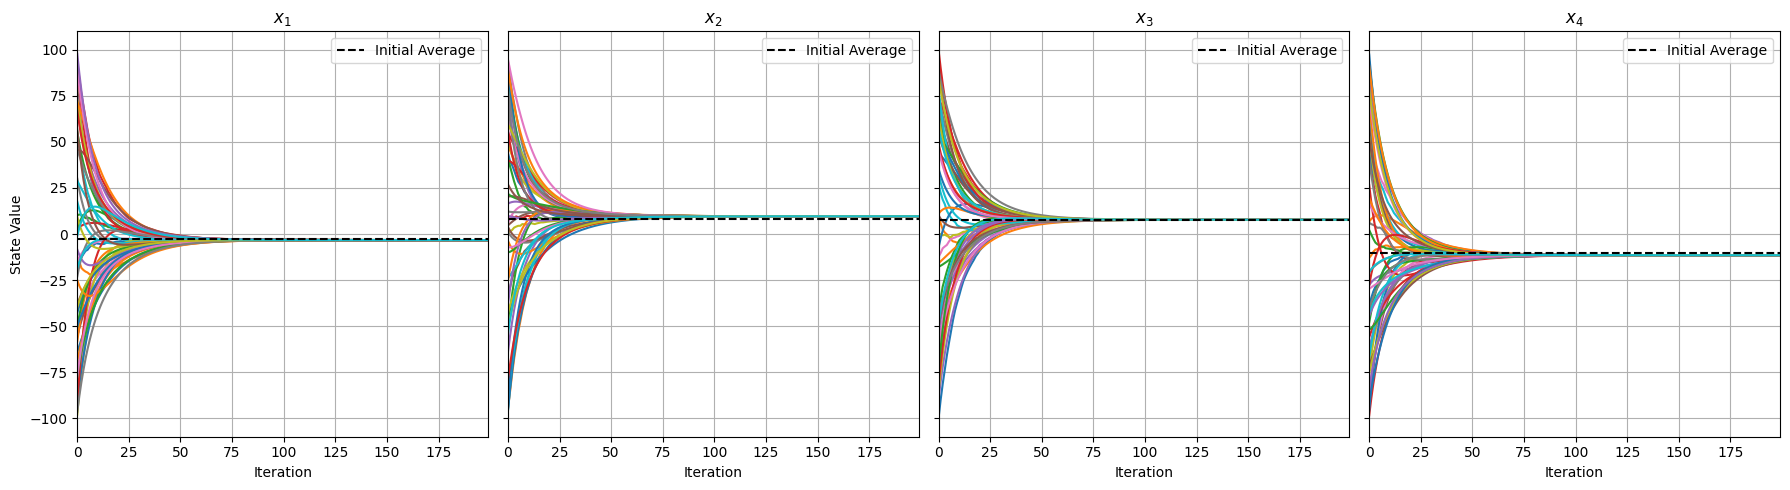

In [19]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = wmsr_data[i]
        for j in range(N_STATE):
            axes[j].plot(states[:, j])

    initial_states = [wmsr_data[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        axes[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Initial Average"
        )

    for j in range(N_STATE):
        axes[j].set_xlabel("Iteration")
        axes[j].set_xlim(0, N_ITER - 1)
        axes[j].set_title(f"$x_{j + 1}$")
        axes[j].grid()
        axes[j].legend()

    axes[0].set_ylabel("State Value")

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "wmsr_states.pdf", format="pdf")

# 7. Improved ADRC algorithm

1. Exchange the current state

   Each node $i$ broadcasts its current state and receives the states of its neighbors:
   $$
   x_j(t), \quad \forall j \in \mathcal{N}_i.
   $$

2. Compute neighbor $F_i$-safe point
   $$
   s_i(t) = \operatorname{IteratedRadon}(\big\{x_{j}(t)\big\}_{j\in\mathcal N_i}) \quad \text{or} \quad s_i(t) = \operatorname{IteratedTverberg}(\big\{x_{j}(t)\big\}_{j\in\mathcal N_i})
   $$

3. Update local state

   Node $i$ updates its state by mixing its local value and the neighbor trimmed mean:
   $$
   x_i(t+1) = (1-\alpha) x_i(t) + \alpha s_{i}(t),
   $$
   where $\alpha \in (0,1]$.

---

## (1) Run the algorithm

In [16]:
def adrc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import ADRC

    agent = ADRC(nh, alpha)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        adrc_results = {
            i: pool.apply_async(adrc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(
                byzantine_node, args=(i, N_STATE, ALPHA, N_ITER, ATTACKER_MODEL)
            )
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        adrc_data = {i: node.get() for i, node in adrc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:46527
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '55' joined graph 'default' from 10.20.13.39:46425.
INFO:topolink.graph:Node '6' joined graph 'default' from 10.20.13.39:45849.
INFO:topolink.graph:Node '46' joined graph 'default' from 10.20.13.39:46491.
INFO:topolink.graph:Node '41' joined graph 'default' from 10.20.13.39:46139.
INFO:topolink.graph:Node '19' joined graph 'default' from 10.20.13.39:44693.
INFO:topolink.graph:Node '1' joined graph 'default' from 10.20.13.39:44631.
INFO:topolink.graph:Node '38' joined graph 'default' from 10.20.13.39:45195.
INFO:topolink.graph:Node '28' joined graph 'default' from 10.20.13.39:46039.
INFO:topolink.graph:Node '9' joined graph 'default' from 10.20.13.39:46375.
INFO:topolink.graph:Node '60' joined graph 'default' from 10.20.13.39:45031.
INFO:topolink.graph:Node '16' joined graph 'default' from 10.20.13.39:45717.
INFO:topolink.graph:N

## (2) Visualize the Results

### 1. State evolution for each normal node

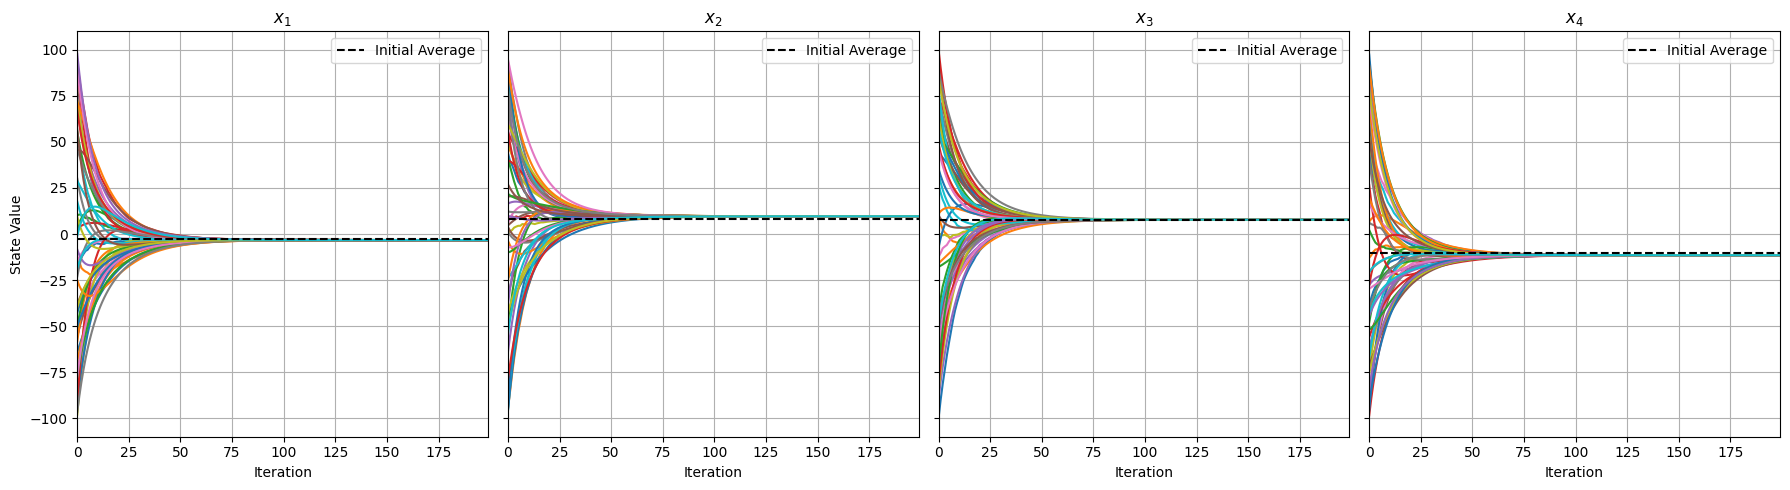

In [20]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes: tp.Sequence[maxes.Axes]
    fig, axes = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = wmsr_data[i]
        for j in range(N_STATE):
            axes[j].plot(states[:, j])

    initial_states = [wmsr_data[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        axes[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Initial Average"
        )

    for j in range(N_STATE):
        axes[j].set_xlabel("Iteration")
        axes[j].set_xlim(0, N_ITER - 1)
        axes[j].set_title(f"$x_{j + 1}$")
        axes[j].grid()
        axes[j].legend()

    axes[0].set_ylabel("State Value")

    fig.tight_layout()

    fig.savefig(FIGURE_PATH / ATTACKER_MODEL / "adrc_states.pdf", format="pdf")